In [35]:
import os
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import keras
from keras.utils import load_img, img_to_array, to_categorical
from keras import layers, models, regularizers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.callbacks import EarlyStopping
import keras_tuner as kt

** Data Understanding **

In [2]:
# Dataset path
dataset_path = "fruit_dataset/"
for dirpath, dirnames, filenames in os.walk(dataset_path):
    print(f"{len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

15 directories and 0 images in 'fruit_dataset/'.
0 directories and 5024 images in 'fruit_dataset/Apple'.
0 directories and 3027 images in 'fruit_dataset/Banana'.
0 directories and 2080 images in 'fruit_dataset/Carambola'.
0 directories and 4008 images in 'fruit_dataset/Guava'.
0 directories and 4173 images in 'fruit_dataset/Kiwi'.
0 directories and 4154 images in 'fruit_dataset/Mango'.
0 directories and 2078 images in 'fruit_dataset/muskmelon'.
0 directories and 3012 images in 'fruit_dataset/Orange'.
0 directories and 2629 images in 'fruit_dataset/Peach'.
0 directories and 3012 images in 'fruit_dataset/Pear'.
0 directories and 2072 images in 'fruit_dataset/Persimmon'.
0 directories and 2501 images in 'fruit_dataset/Pitaya'.
0 directories and 2298 images in 'fruit_dataset/Plum'.
0 directories and 2167 images in 'fruit_dataset/Pomegranate'.
0 directories and 2171 images in 'fruit_dataset/Tomatoes'.


In [3]:
# Show class names
data_dir = pathlib.Path(dataset_path)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['Apple' 'Banana' 'Carambola' 'Guava' 'Kiwi' 'Mango' 'Orange' 'Peach'
 'Pear' 'Persimmon' 'Pitaya' 'Plum' 'Pomegranate' 'Tomatoes' 'muskmelon']


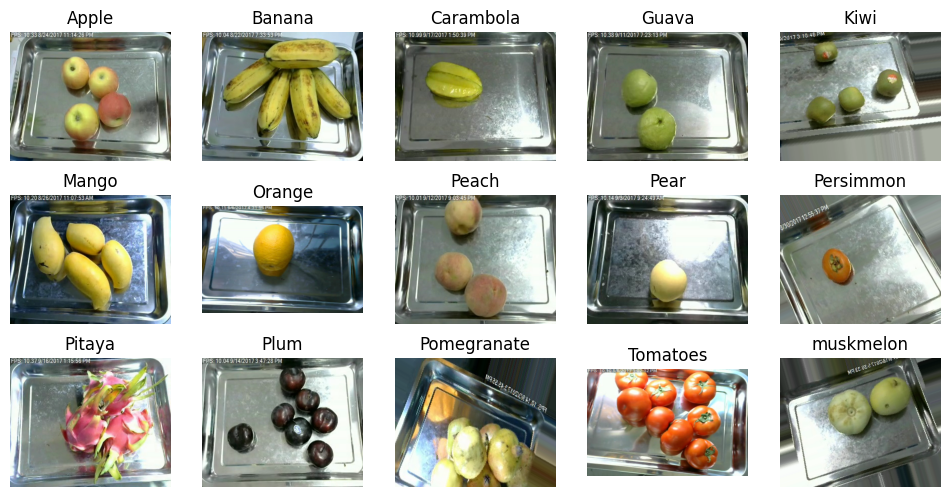

In [4]:
# Plot a grid of images from train dataset
def view_random_image(target_dir, target_class):
  target_folder = target_dir + target_class
  random_image = random.sample(os.listdir(target_folder), 100)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  return img

# View a random image from train dataset for all classes
plt.figure(figsize=(12,6))
for i in range(15):
    plt.subplot(3,5,i+1)
    img = view_random_image(target_dir=dataset_path,
                            target_class=class_names[i])

In [5]:
# Prepare Pandas DataFrame
data_obj = {'path': [], 'filename': [], 'label': []}
for dirpath, dirnames, filenames in os.walk(dataset_path):
    for f in filenames:
        full_path = os.path.join(dirpath, f)
        label = os.path.basename(os.path.dirname(full_path))
        data_obj['path'].append(dirpath)
        data_obj['filename'].append(f)
        data_obj['label'].append(label)

data_df = pd.DataFrame(data_obj)
data_df.sample(n=10)

,path,filename,label
30180,fruit_dataset/Peach,Peach00995.png,Peach
10304,fruit_dataset/Guava,Guava01154.png,Guava
33466,fruit_dataset/Persimmon,Persimmon1240.png,Persimmon
8372,fruit_dataset/Carambola,Carambola 001288.png,Carambola
17259,fruit_dataset/Kiwi,Kiwi003807.png,Kiwi
20814,fruit_dataset/Mango,Mango003250.png,Mango
23765,fruit_dataset/muskmelon,Muskmelon 00297.png,muskmelon
23407,fruit_dataset/muskmelon,Muskmelon 001848.png,muskmelon
35101,fruit_dataset/Persimmon,Persimmon848.png,Persimmon
16716,fruit_dataset/Kiwi,Kiwi003318.png,Kiwi


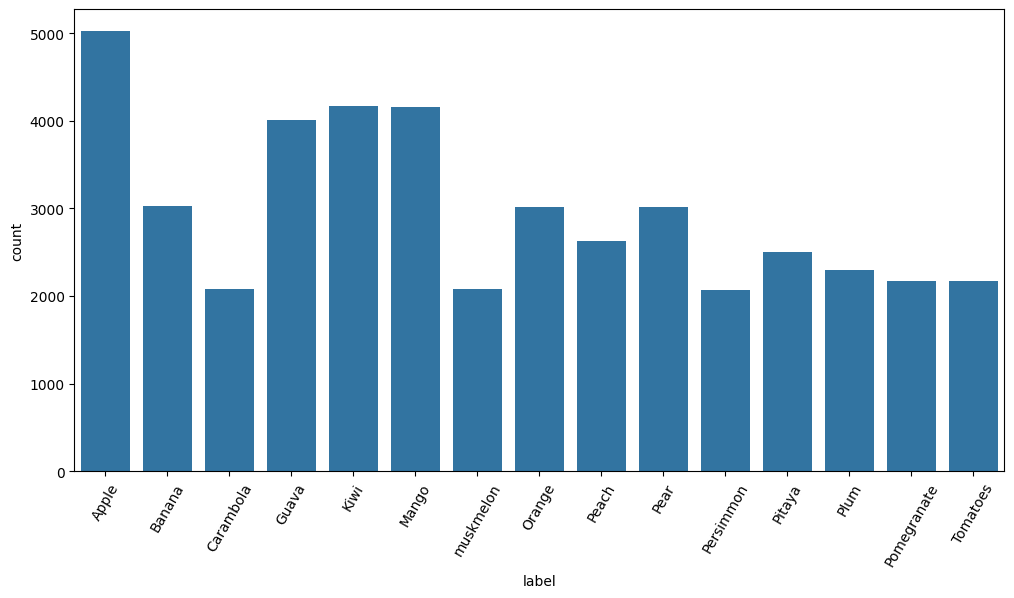

In [6]:
# Plot the number of images of each classes
plt.figure(figsize=(12,6))
sns_cntplot = sns.countplot(x='label', data=data_df)
plt.xticks(rotation=60)
plt.show()

** Data Preparation **

In [7]:
# Read images and create numpy data array
images = []
label = [] 

for _, d in data_df.iterrows():
    img = load_img(os.path.join(d['path'], d['filename']), target_size=(150,150))
    images.append(img_to_array(img))
    label.append(d['label'])

images = np.array(images)
labels = np.array(label)
print(f"Data images shape: {images.shape} and label shape: {labels.shape}")

Data images shape: (44406, 150, 150, 3) and label shape: (44406,)


In [8]:
# One-hot encoding
class_indices = dict(zip(class_names, range(len(class_names))))
labels_encoded = list(map(class_indices.get, labels))
label_categorical = to_categorical(labels_encoded, num_classes=len(class_names))

In [9]:
# Data splitting
train_im, val_test_im, train_lab, val_test_lab = train_test_split(
    images,
    label_categorical,
    test_size = 0.3,
    stratify=label_categorical,
    random_state = 100,
    shuffle = True
)

valid_im, test_im, valid_lab, test_lab = train_test_split(
    val_test_im,
    val_test_lab,
    test_size = 0.5,
    stratify = val_test_lab,
    random_state = 100,
    shuffle = True
)

In [10]:
# Data shape
print ("Train data shape: ", train_im.shape)
print ("Train label shape: ", train_lab.shape)
print ('Validation data shape: ', valid_im.shape)
print ("Validation label shape: ", valid_lab.shape)
print ('Test data shape: ', test_im.shape)
print ("Test label shape: ", test_lab.shape)

Train data shape:  (31084, 150, 150, 3)
Train label shape:  (31084, 15)
Validation data shape:  (6661, 150, 150, 3)
Validation label shape:  (6661, 15)
Test data shape:  (6661, 150, 150, 3)
Test label shape:  (6661, 15)


In [11]:
training_data = tf.data.Dataset.from_tensor_slices((train_im, train_lab))
validation_data = tf.data.Dataset.from_tensor_slices((valid_im, valid_lab))
testing_data = tf.data.Dataset.from_tensor_slices((test_im, test_lab))

In [12]:
# Data Pipeline, Normalization and Prefetching
rescale_data = Sequential([
    layers.Rescaling(1/255)
])
batch_size = 128
autotune = tf.data.AUTOTUNE

def prepare(ds, shuffle=False):
    ds = ds.map(lambda x, y: (rescale_data(x), y), num_parallel_calls=autotune)
    
    if shuffle:
        ds = ds.shuffle(1000)
    
    # batch data
    ds = ds.batch(batch_size)
    
    # Use buffered prefetching on all datasets
    return ds.prefetch(buffer_size=autotune)

train_ds = prepare(training_data, shuffle=True)
val_ds = prepare(validation_data)
test_ds = prepare(testing_data)

** Model Building (FNN) **

In [32]:
model = Sequential()

model.add(Flatten(input_shape=(150,150,3)))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))

model.add(Dense(len(class_names), activation='softmax'))

model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 512)            │    34,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,733,967 (132.50 MB)

 Trainable params: 34,733,967 (132.50 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
#Early stopping
early_stopping = EarlyStopping(
    patience = 10,
    restore_best_weights = True
)

# Model training
history = model.fit(
    train_ds,
    epochs = 40,
    validation_data = val_ds,
    callbacks = early_stopping
)

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 79s 316ms/step - accuracy: 0.1136 - loss: 3.3137 - val_accuracy: 0.1686 - val_loss: 2.5163
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 341ms/step - accuracy: 0.1395 - loss: 2.5490 - val_accuracy: 0.1776 - val_loss: 2.4375
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 82s 338ms/step - accuracy: 0.1506 - loss: 2.5091 - val_accuracy: 0.1941 - val_loss: 2.4003
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 82s 335ms/step - accuracy: 0.1604 - loss: 2.4794 - val_accuracy: 0.2124 - val_loss: 2.3280
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 81s 335ms/step - accuracy: 0.1610 - loss: 2.4774 - val_accuracy: 0.1973 - val_loss: 2.3547
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 341ms/step - accuracy: 0.1692 - loss: 2.4427 - val_accuracy: 0.2297 - val_loss: 2.2567
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 80s 328ms/step - accuracy: 0.1752 - loss: 2.4205 - val_accuracy: 0.2048 - val_loss: 2.3137
Epoch 8/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 77s 316ms/step - accuracy: 0.1815 - loss: 2

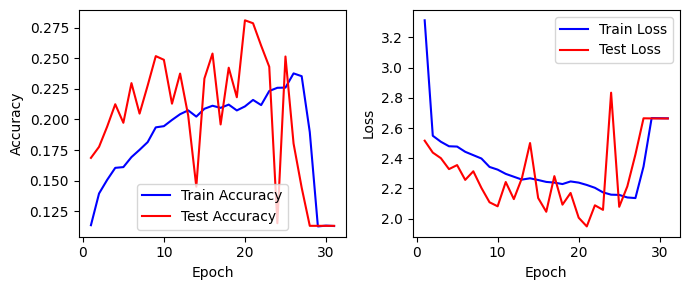

In [34]:
# Model history plotting
acc2 = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss2 = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc2)+1)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].plot(epochs, acc2,'b',label='Train Accuracy')
axes[0].plot(epochs, val_acc,'r',label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, loss2,'b',label='Train Loss')
axes[1].plot(epochs, val_loss,'r',label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

plt.show()

** Model Tuning **

In [36]:
def build_model(hp):
    model = Sequential()
    
    model.add(Flatten(input_shape=(150,150,3)))

    model.add(Dense(
        units=hp.Choice('dense1_units', values=[256, 512]),
        activation='relu'
    ))
    
    model.add(Dense(
        units=hp.Choice('dense2_units', values=[128, 256]),
        activation='relu'
    ))
    
    model.add(Dense(
        units=hp.Choice('dense3_units', values=[64, 128]),
        activation='relu'
    ))
    
    model.add(Dense(64, activation='relu'))

    model.add(Dense(len(class_names), activation='softmax'))
    
    # Optimizer learning rate tuning
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# Instantiate tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='fnn_tuning'
)

# Run tuner
tuner.search(train_ds, epochs=10, validation_data=val_ds)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 5 Complete [00h 06m 49s]
val_accuracy: 0.1130460873246193

Best val_accuracy So Far: 0.8552770018577576
Total elapsed time: 00h 56m 17s


c:\Users\zhenc\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    17,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,367,631 (66.25 MB)

 Trainable params: 17,367,631 (66.25 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Best model training
history = best_model.fit(
    train_ds,
    epochs = 40,
    validation_data = val_ds,
    callbacks = early_stopping
)

Epoch 1/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.8455 - loss: 0.5034 - val_accuracy: 0.8500 - val_loss: 0.4575
Epoch 2/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 39s 160ms/step - accuracy: 0.8757 - loss: 0.3627 - val_accuracy: 0.8482 - val_loss: 0.4666
Epoch 3/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - accuracy: 0.8679 - loss: 0.3851 - val_accuracy: 0.8508 - val_loss: 0.4494
Epoch 4/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - accuracy: 0.8821 - loss: 0.3370 - val_accuracy: 0.8467 - val_loss: 0.4460
Epoch 5/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 42s 171ms/step - accuracy: 0.8710 - loss: 0.3679 - val_accuracy: 0.8628 - val_loss: 0.3884
Epoch 6/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 41s 170ms/step - accuracy: 0.8889 - loss: 0.3190 - val_accuracy: 0.8436 - val_loss: 0.4598
Epoch 7/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 42s 173ms/step - accuracy: 0.8790 - loss: 0.3510 - val_accuracy: 0.8587 - val_loss: 0.4095
Epoch 8/40
243/243 ━━━━━━━━━━━━━━━━━━━━ 44s 180ms/step - accuracy: 0.8862 - loss: 0

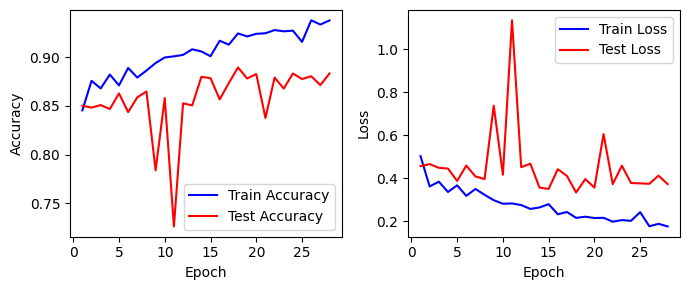

In [38]:
# Tuned best model history plotting
acc2 = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss2 = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc2)+1)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3))
axes[0].plot(epochs, acc2,'b',label='Train Accuracy')
axes[0].plot(epochs, val_acc,'r',label='Test Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs, loss2,'b',label='Train Loss')
axes[1].plot(epochs, val_loss,'r',label='Test Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

plt.show()

** Model Evaluation **

In [39]:
# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 405ms/step - accuracy: 0.8885 - loss: 0.3520
Test Loss: 0.3520
Test Accuracy: 0.8885


In [40]:
# Get predictions
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds])

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Confusion Matrix:
[[640   3   5  11   3   6   7   9  11   3  19   0   0  16  21]
 [  6 387   3   2  12  23   1   0  11   0   0   0   2   0   7]
 [  0   6 296   6   0   1   0   0   2   0   0   0   0   0   1]
 [ 20  10  14 529   6   6   0   0   5   0   0   0   0   0  11]
 [ 12   1   0   4 587   2   1   0  11   4   0   0   0   1   3]
 [ 13  29   3   7   7 538   5   0  10   1   0   1   1   0   8]
 [  8   5   0   1   0   8 413   1   4   9   0   0   2   0   1]
 [ 32   0   0   0   3   0   4 345   2   0   8   0   0   1   0]
 [ 24   4   0   8   4  22   4   0 382   0   0   1   0   0   3]
 [  8   0   0   0   0   0   8   0   0 295   0   0   0   0   0]
 [ 18   0   0   0   0   0   0   2   0   1 349   0   0   5   0]
 [  0   0   0   0   0   0   0   0   0   0   0 344   0   0   0]
 [  4  18   2   3   4  24   8   1   3   3   0   0 254   0   1]
 [ 34   0   0   0   0   0   0   1   0   2  14   0   1 273   0]
 [  7   0   0   7   1   5   0   0   5   0   0   0   1   0 28

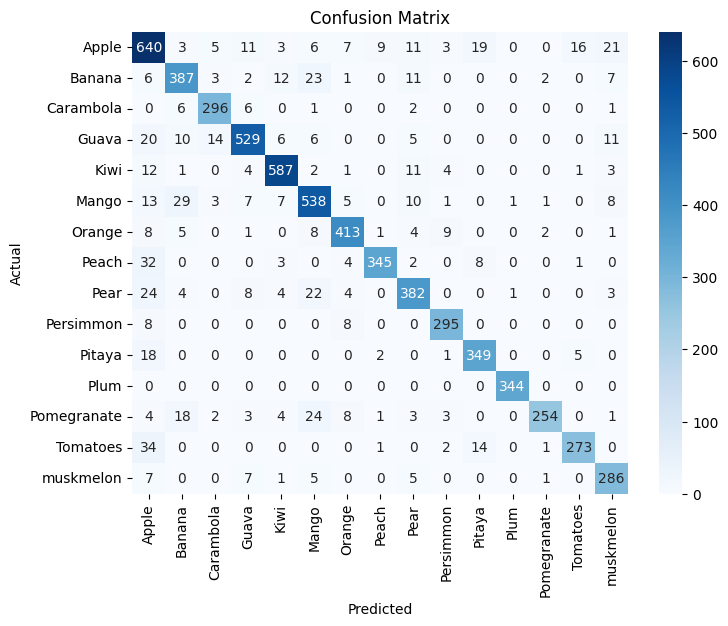

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()